# Project 3 - Aircraft Classification

## Experiment 1: Unfrozen ResNet18 + AdamW + CosineAnnealingLR

Import essential libraries and default configurations

In [1]:
# Reload all modules before executing the notebook
%load_ext autoreload
%autoreload 2

In [2]:
from utils import set_seed, plot_class_distribution, setup_model, train_epoch, eval_epoch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn for machine learning utilities
from sklearn.model_selection import train_test_split

# Torch for deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Torchvision for datasets and transformations
import torchvision
import torchvision.transforms as transforms

# Progress bar for loops
import tqdm
import copy
import random

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fix random seedataset for reproducibility
set_seed(42)

Using device: cuda


## Data Preprocessing

Number of training/validation samples: 1331
Number of test samples: 669


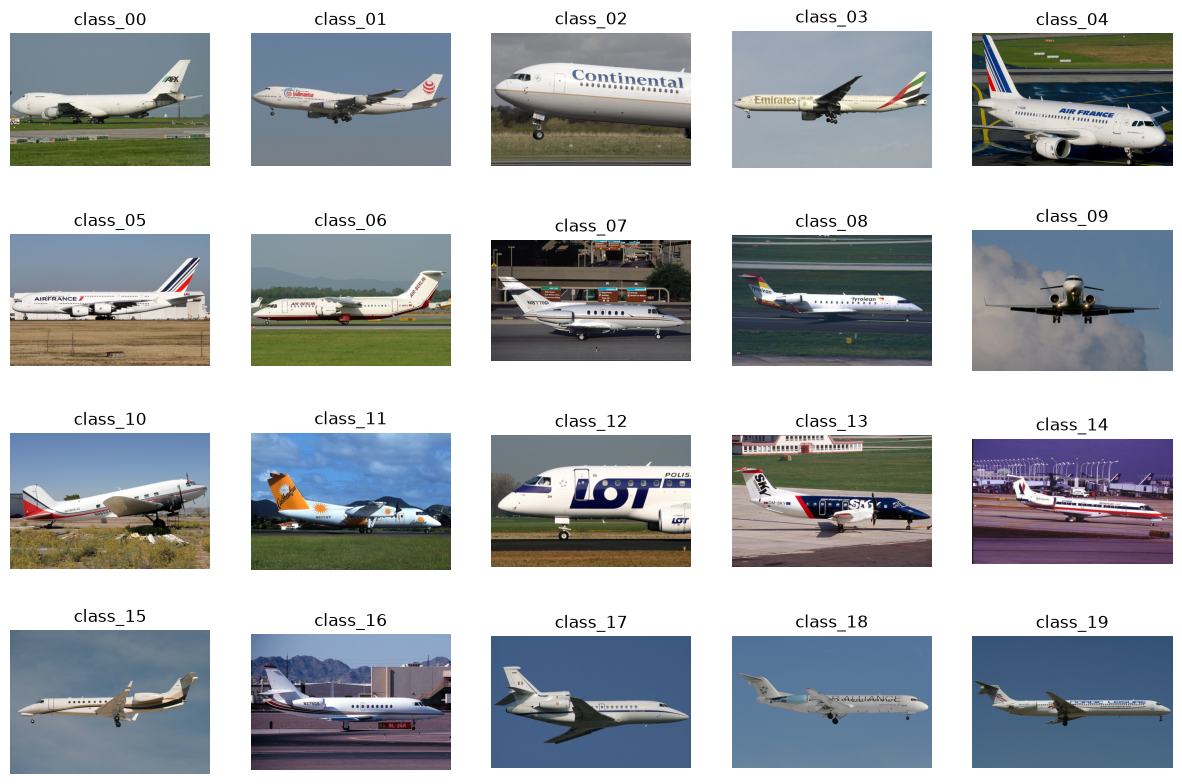

In [4]:
# Load dataset
trainval_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/trainval')
test_dataset = torchvision.datasets.ImageFolder('FGVCAircraft_Subset20/test')

print(f"Number of training/validation samples: {len(trainval_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

# Get class names
class_names = trainval_dataset.classes
dataset_labels = np.array([label for _, label in trainval_dataset.samples])

# Plot one random sample from each class in the training/validation dataset
num_classes = len(trainval_dataset.classes)
plt.figure(figsize=(15, 10))

# For each class, select a random sample and plot it
for i in range(num_classes):
    class_indices = [j for j, (_, label) in enumerate(trainval_dataset.samples) if label == i]
    random_index = random.choice(class_indices)
    image, label = trainval_dataset[random_index]
    plt.subplot(4, 5, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis('off')

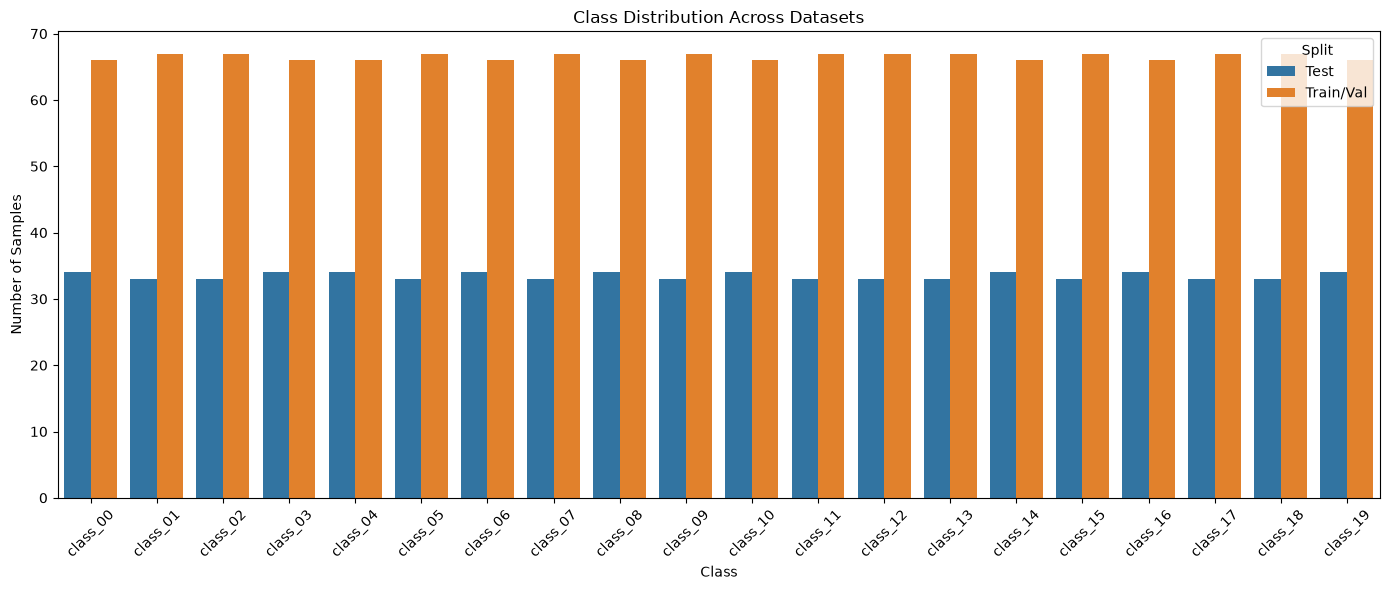

In [5]:
# Plot class distribution of the training/validation and test dataset

plot_class_distribution(trainval_dataset, test_dataset, dataset_names=['Train/Val', 'Test'])

Total training/validation samples: 1331
Number of training samples: 1064
Number of validation samples: 267


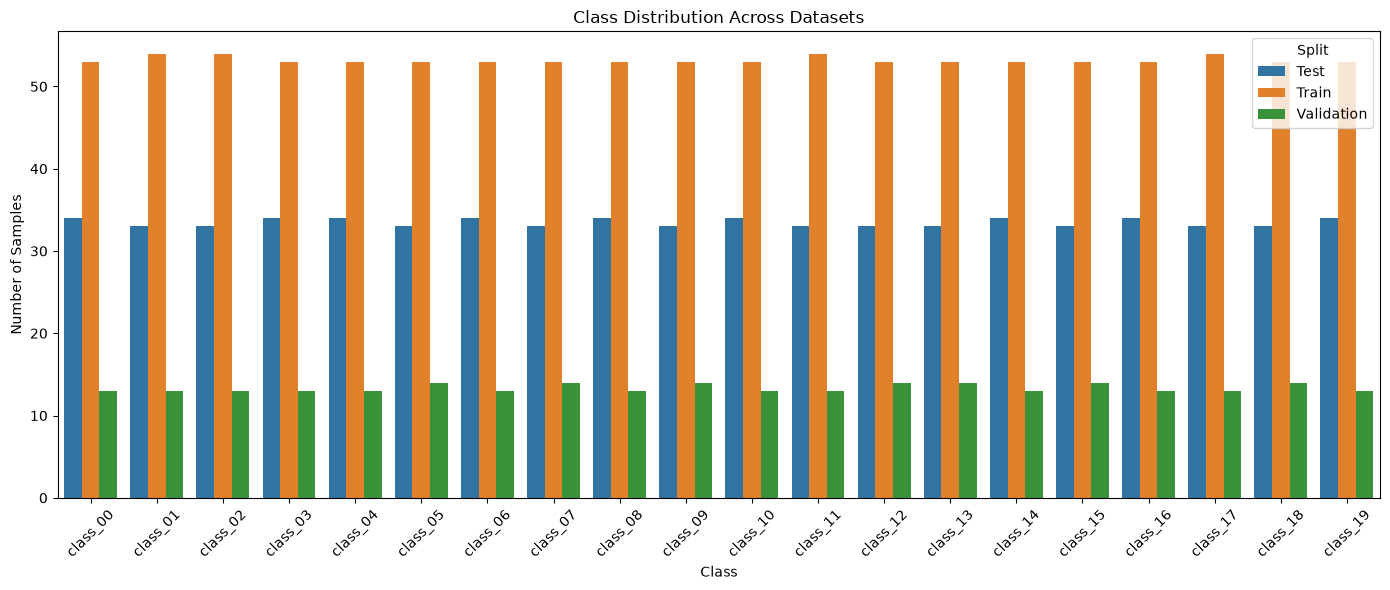

In [6]:
# Splitting dataset
indices = list(range(len(trainval_dataset)))
labels = [label for _, label in trainval_dataset.samples]

# Perform stratified split to maintain class distribution
train_indices, val_indices = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=42)

# Create subset datasets
train_dataset = torch.utils.data.Subset(trainval_dataset, train_indices)
val_dataset = torch.utils.data.Subset(copy.deepcopy(trainval_dataset), val_indices)

print(f"Total training/validation samples: {len(trainval_dataset)}")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
plot_class_distribution(train_dataset, val_dataset, test_dataset, dataset_names=['Train', 'Validation', 'Test'])

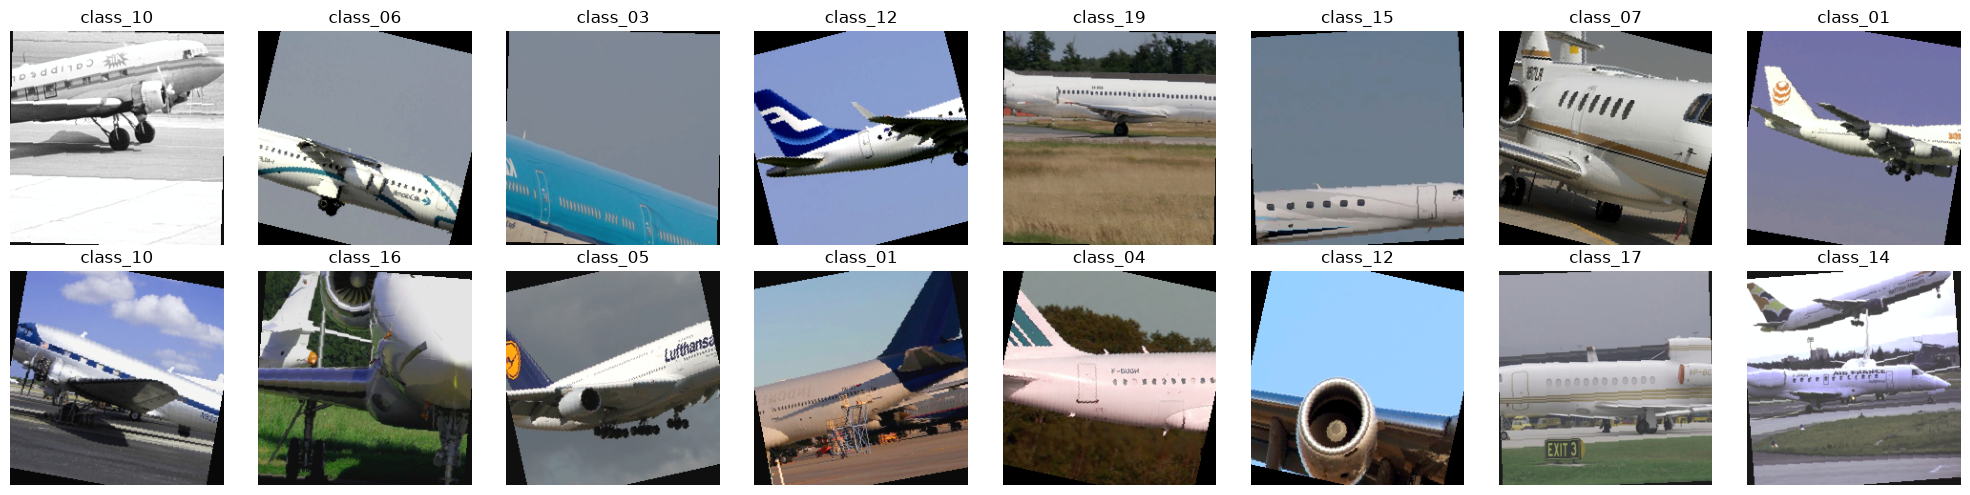

In [7]:
# Imagenet preprocessing
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Base transformation (tensor + norm)
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Validation / Test transform
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    base_transform
])

# Data augmentation transformations for training dataset
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    base_transform
])

# Apply transformations to datasets
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

# Create DataLoaders for training, validation, and test datasets
batch_size = 16
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Visualize a batch of training images
data_iter = iter(train_loader)
images, labels = next(data_iter)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes = axes.ravel()
for i in range(min(16, len(images))):
    img = images[i].numpy().transpose((1, 2, 0))  # Convert from (C, H, W) to (H, W, C)
    img = img * np.array(imagenet_std) + np.array(imagenet_mean)  # Unnormalize
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Model

In [8]:
# Initialize Unfrozen ResNet-18
backbone_model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_unfrozen = setup_model(backbone_model, 20, freeze_backbone=False, device=device)
print("Initialized Unfrozen ResNet-18")
resnet_unfrozen

Initialized Unfrozen ResNet-18


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Training Loop

  3%|▎         | 1/32 [00:08<04:18,  8.34s/it]

Epoch [  1/32] | train_loss: 2.9504 | train_acc: 0.1212 | val_loss: 3.5175 | val_acc: 0.1217
Best model found at epoch 0 with accuracy of 0.122


  6%|▋         | 2/32 [00:16<04:02,  8.07s/it]

Epoch [  2/32] | train_loss: 2.5773 | train_acc: 0.1898 | val_loss: 2.4683 | val_acc: 0.2522
Best model found at epoch 1 with accuracy of 0.252


  9%|▉         | 3/32 [00:23<03:47,  7.84s/it]

...

Epoch [ 30/32] | train_loss: 0.5979 | train_acc: 0.8139 | val_loss: 0.5733 | val_acc: 0.8308


 97%|█████████▋| 31/32 [04:03<00:07,  7.88s/it]

Epoch [ 31/32] | train_loss: 0.5826 | train_acc: 0.8111 | val_loss: 0.5582 | val_acc: 0.8343
Best model found at epoch 30 with accuracy of 0.834


100%|██████████| 32/32 [04:11<00:00,  7.85s/it]


Epoch [ 32/32] | train_loss: 0.5657 | train_acc: 0.8177 | val_loss: 0.5524 | val_acc: 0.8269


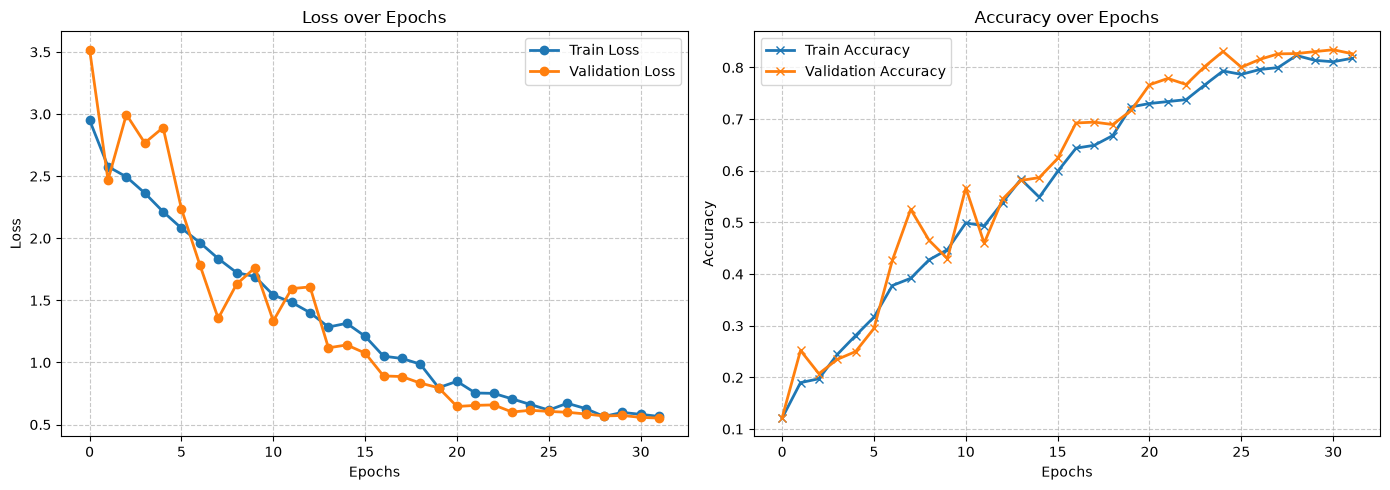

In [9]:
# Hyperparmeters setup
lr = 0.001
total_epochs = 32

# Define a loss function
criterion = nn.CrossEntropyLoss()

# Initialise the AdamW optimizer (filter out frozen parameters)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, resnet_unfrozen.parameters()), lr=lr, weight_decay=1e-4
)

# Initialize Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs)

# For n epochs
total_train_loss, total_val_loss = [], []
total_train_acc, total_val_acc = [], []
best_acc = -np.inf

epoch_pbar = tqdm.tqdm(range(total_epochs), colour='blue')
for epoch in epoch_pbar:
    # Train for 1 epoch
    mean_train_loss, train_accuracy = train_epoch(resnet_unfrozen, train_loader, criterion, optimizer, epoch, device)
    total_train_loss.append(mean_train_loss)
    total_train_acc.append(train_accuracy)

    # Step the scheduler
    scheduler.step()

    # Evaluate on validation set
    mean_val_loss, val_accuracy = eval_epoch(
        resnet_unfrozen, val_loader, criterion, epoch, device
    )
    total_val_loss.append(mean_val_loss)
    total_val_acc.append(val_accuracy)
    
    # Print formatted string above the progress bar
    epoch_pbar.write(f"Epoch [{epoch+1:3d}/{total_epochs}] | train_loss: {mean_train_loss:.4f} | train_acc: {train_accuracy:.4f} | val_loss: {mean_val_loss:.4f} | val_acc: {val_accuracy:.4f}")

    # Save the best model based on validation accuracy
    if val_accuracy > best_acc:
        torch.save(resnet_unfrozen.state_dict(), "resnet_unfrozen_h1_best.pth")
        best_acc = val_accuracy
        print(f"Best model found at epoch {epoch} with accuracy of {best_acc:.3f}")

# Plot training and validation loss and accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss subplot
axes[0].plot(total_train_loss, label='Train Loss', marker='o', linewidth=2)
axes[0].plot(total_val_loss, label='Validation Loss', marker='o', linewidth=2)
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')

# Accuracy subplot
axes[1].plot(total_train_acc, label='Train Accuracy', marker='x', linewidth=2)
axes[1].plot(total_val_acc, label='Validation Accuracy', marker='x', linewidth=2)
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('training_results_model_h1.png')
plt.show()

In [10]:
import pickle
weights_model_h1 = {
    'train_loss': total_train_loss, 'val_loss': total_val_loss,
    'train_acc': total_train_acc, 'val_acc': total_val_acc
}
with open('weights_model_h1.pkl', 'wb') as f:
    pickle.dump(weights_model_h1, f)
print("Saved training history to weights_model_h1.pkl")

Saved training history to weights_model_h1.pkl
